# 现代卷积神经网络

## 深度卷积神经网络(AlexNet)

当⼈们和机器学习研究⼈员交谈时，会发现机器学习研究⼈员相信机器学习既重要⼜美丽：优雅的理论去证明各种模型的性质。机器学习是⼀个正在蓬勃发展、严谨且⾮常有⽤的领域。然⽽，当⼈们和计算机视觉研究⼈员交谈，会听到⼀个完全不同的故事。计算机视觉研究⼈员会告诉⼀个诡异事实————推动领域进步的是数据特征，⽽不是学习算法。计算机视觉研究⼈员相信，从对最终模型精度的影响来说，更⼤或更⼲净的数据集、或是稍微改进的特征提取，⽐任何学习算法带来的进步要⼤得多。（我也更认同后者）

### AlexNet

AlexNet通过暂退法控制全连接层的模型复杂度，⽽LeNet只使⽤了权重衰减(正则化)。为了进⼀步扩充数据，AlexNet在训练时增加了⼤量的图像增强数据，如翻转、裁切和变⾊。这使得模型更健壮，更⼤的样本量有效地减少了过拟合。

In [2]:
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(
    # 这里使用一个11*11的更大窗口来捕捉对象。
    # 同时，步幅为4，以减少输出的高度和宽度。
    # 另外，输出通道的数目远大于LeNet
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 减小卷积窗口，使用填充为2来使得输入与输出的高和宽一致，且增大输出通道数
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 使用三个连续的卷积层和较小的卷积窗口。
    # 除了最后的卷积层，输出通道的数量进一步增加。
    # 在前两个卷积层之后，汇聚层不用于减少输入的高度和宽度
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    # 这里，全连接层的输出数量是LeNet中的好几倍。使用dropout层来减轻过拟合
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    # 最后是输出层。由于这里使用Fashion-MNIST,所以类别数为10
    nn.Linear(4096, 10)
)

In [3]:
X = torch.randn(1, 1, 224, 224)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


### 读取数据集

In [4]:
batch_size = 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)

### 训练AlexNet

与之前的LeNet相⽐，这⾥的主要变化是使⽤更⼩的学习速率训练，这是因为⽹络更深更⼴、图像分辨率更⾼，训练卷积神经⽹络就更昂贵。

loss 0.328, train acc 0.881, test acc 0.878
90.2 examples/sec on cpu


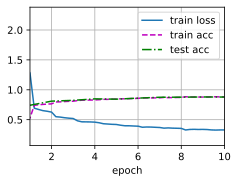

In [5]:
lr, num_epochs = 0.01, 10
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

### 练习

修改批量大小，并观察模型精度和GPU显存变化。

分别对比batch_size为64，128，512时的模型精度和GPU显存变化。\
batch_size=64，显存占用为：3.74GB，模型精度：loss 0.274, train acc 0.898, test acc 0.895\
batch_size=128，显存占用为：7.93GB，模型精度：loss 0.324, train acc 0.880, test acc 0.886\
batch_size=512，显存占用为：7.93GB，模型精度：loss 0.504, train acc 0.811, test acc 0.823\

    在上面的实验中可以看出，batch_size越大运行所需要的显存就越多，模型的精度也会降低。

## 使用块的网络(VGG)

在下⾯的⼏个章节中，我们将介绍⼀些常⽤于设计深层神经⽹络的启发式概念。

### VGG块

经典卷积神经⽹络的基本组成部分是下⾯的这个序列：
1. 带填充以保持分辨率的卷积层；
2. ⾮线性激活函数，如ReLU；
3. 汇聚层，如最⼤汇聚层。

⽽⼀个VGG块与之类似，由⼀系列卷积层组成，后⾯再加上⽤于空间下采样的最⼤汇聚层。

In [6]:
import torch
from torch import nn
from d2l import torch as d2l

def vgg_block(num_convs, in_channels, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels, out_channels,
                                kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        in_channels = out_channels
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)

### VGG网络

In [7]:
# 每个VGG块里卷积层个数和输出通道数
conv_arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))

In [8]:
def vgg(conv_arch):
    conv_blks = []
    in_channels = 1
    # 卷积层部分
    for (num_convs, out_channels) in conv_arch:
        conv_blks.append(vgg_block(num_convs, in_channels, out_channels))
        in_channels = out_channels

    return nn.Sequential(
        *conv_blks, nn.Flatten(),
        # 全链接层部分
        nn.Linear(out_channels * 7 * 7, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 10)
    )

net = vgg(conv_arch)

In [9]:
X = torch.randn(size=(1, 1, 244, 244))
for blk in net:
    X = blk(X)
    print(blk.__class__.__name__, 'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 122, 122])
Sequential output shape:	 torch.Size([1, 128, 61, 61])
Sequential output shape:	 torch.Size([1, 256, 30, 30])
Sequential output shape:	 torch.Size([1, 512, 15, 15])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


### 训练模型

In [10]:
ratio = 4
small_conv_arch = [(pair[0], pair[1] // ratio) for pair in conv_arch]
net = vgg(small_conv_arch)

loss 0.169, train acc 0.938, test acc 0.923
74.1 examples/sec on cpu


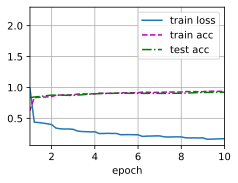

In [11]:
lr, num_epochs, batch_size = 0.05, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## 网络中的网络(NiN)

### NiN块

In [12]:
import torch
from torch import nn
from d2l import torch as d2l

def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU()
    )

### NiN模型

NiN和AlexNet之间的⼀个显著区别是NiN完全取消了全连接层。相反，NiN使⽤⼀个NiN块，其输出通道数等于标签类别的数量。最后放⼀个全局平均汇聚层（global average pooling layer），⽣成⼀个对数⼏率（logits）。NiN设计的⼀个优点是，它显著减少了模型所需参数的数量。然⽽，在实践中，这种设计有时会增加训练模型的时间。

In [15]:
net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小，10)
    nn.Flatten()
)

In [16]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


### 训练模型

In [ ]:
lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## 含并行链接的网络(GoogLeNet)

⼀个重点是解决了什么样⼤⼩的卷积核最合适的问题。毕竟，以前流⾏的⽹络使⽤⼩到1 × 1，⼤到11 × 11的卷积核。本⽂的⼀个观点是，有时使⽤不同⼤⼩的卷积核组合是有利的。

### Inception块

<div align="center">
    <img src="../img/Inception块架构.png">
<div>

在Inception块中，通常调整的超参数是每层输出通道数。

In [19]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

class Inception(nn.Module):
    # c1 -- c4 是每条路径的输出通道数
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # 线路1，单1x1卷积层
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        # 线路2，1x1卷积后接3x3卷积层
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        # 线路3，1x1卷积层后接5x5卷积层
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        # 线路4，3x3最大汇聚层后接1x1卷积层
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)

    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        # 在通道维度上连结输出
        return torch.cat((p1, p2, p3, p4), dim=1)

那么为什么GoogLeNet这个⽹络如此有效呢？⾸先我们考虑⼀下滤波器（filter）的组合，它们可以⽤各种滤波器尺⼨探索图像，这意味着不同⼤⼩的滤波器可以有效地识别不同范围的图像细节。同时，我们可以为不同的滤波器分配不同数量的参数。

### GoodLeNet模型

In [20]:
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [21]:
b2 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=1),
                    nn.ReLU(),
                    nn.Conv2d(64, 192, kernel_size=3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第三个模块串联两个完整的Inception块。第⼀个Inception块的输出通道数为64 + 128 + 32 + 32 = 256，四个路径之间的输出通道数量⽐为64 : 128 : 32 : 32 = 2 : 4 : 1 : 1。第⼆个和第三个路径⾸先将输⼊通道的数量分别减少到96/192 = 1/2和16/192 = 1/12，然后连接第⼆个卷积层。第⼆个Inception块的输出通道数增加到128 + 192 + 96 + 64 = 480，四个路径之间的输出通道数量⽐为128 : 192 : 96 : 64 = 4 : 6 : 3 : 2。第⼆条和第三条路径⾸先将输⼊通道的数量分别减少到128/256 = 1/2和32/256 = 1/8。

In [22]:
b3 = nn.Sequential(Inception(192, 64, (96, 128), (16, 32), 32),
                    Inception(256, 128, (128, 192), (32, 96), 64),
                    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第四模块更加复杂，它串联了5个Inception块，其输出通道数分别是192 + 208 + 48 + 64 = 512、160 + 224 + 64 + 64 = 512、128 + 256 + 64 + 64 = 512、112 + 288 + 64 + 64 = 528和256 + 320 + 128 + 128 = 832。这些路径的通道数分配和第三模块中的类似，⾸先是含3×3卷积层的第⼆条路径输出最多通道，其次是仅含1×1卷积层的第⼀条路径，之后是含5×5卷积层的第三条路径和含3×3最⼤汇聚层的第四条路径。其中第⼆、第三条路径都会先按⽐例减⼩通道数。这些⽐例在各个Inception块中都略有不同。

In [23]:
b4 = nn.Sequential(Inception(480, 192, (96, 208), (16, 48), 64),
                    Inception(512, 160, (112, 224), (24, 64), 64),
                    Inception(512, 128, (128, 256), (24, 64), 64),
                    Inception(512, 112, (144, 288), (32, 64), 64),
                    Inception(528, 256, (160, 320), (32, 128), 128),
                    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第五模块包含输出通道数为256 + 320 + 128 + 128 = 832和384 + 384 + 128 + 128 = 1024的两个Inception块。其中每条路径通道数的分配思路和第三、第四模块中的⼀致，只是在具体数值上有所不同。需要注意的是，第五模块的后⾯紧跟输出层，该模块同NiN⼀样使⽤全局平均汇聚层，将每个通道的⾼和宽变成1。最后我们将输出变成⼆维数组，再接上⼀个输出个数为标签类别数的全连接层。

In [24]:
b5 = nn.Sequential(Inception(832, 256, (160, 320), (32, 128), 128),
                    Inception(832, 384, (192, 384), (48, 128), 128),
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten())

net = nn.Sequential(b1, b2, b3, b4, b5, nn.Linear(1024, 10))

In [25]:
X = torch.rand(size=(1, 1, 96, 96))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 192, 12, 12])
Sequential output shape:	 torch.Size([1, 480, 6, 6])
Sequential output shape:	 torch.Size([1, 832, 3, 3])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


### 训练模型

KeyboardInterrupt: 

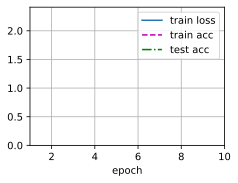

In [26]:
lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## 批量规范化(BN)

本节将介绍批量规范化（batch normalization），这是⼀种流⾏且有效的技术，可持续加速深层⽹络的收敛速度。再结合在7.6节中将介绍的残差块，批量规范化使得研究⼈员能够训练100层以上的⽹络。

### 训练深层网络

直观地说，标准化可以很好地与我们的优化器配合使⽤，因为它可以将参数的量级进⾏统⼀。

当我们训练时，中间层中的变量（例如，多层感知机中的仿射变换输出）可能具有更⼴的变化范围：不论是沿着从输⼊到输出的层，跨同⼀层中的单元，或是随着时间的推移，模型参数的随着训练更新变幻莫测。批量规范化的发明者⾮正式地假设，这些变量分布中的这种偏移可能会阻碍⽹络的收敛。直观地说，我们可能会猜想，如果⼀个层的可变值是另⼀层的100倍，这可能需要对学习率进⾏补偿调整。

更深层的⽹络很复杂，容易过拟合。这意味着正则化变得更加重要。

    批量规范化应⽤于单个可选层（也可以应⽤到所有层），其原理如下：在每次训练迭代中，我们⾸先规范化输⼊，即通过减去其均值并除以其标准差，其中两者均基于当前⼩批量处理。接下来，我们应⽤⽐例系数和⽐例偏移。正是由于这个基于批量统计的标准化，才有了批量规范化的名称。

请注意，**如果我们尝试使⽤⼤⼩为1的⼩批量应⽤批量规范化，我们将⽆法学到任何东西**。这是因为在减去均值之后，每个隐藏单元将为0。所以，只有使⽤⾜够⼤的⼩批量，批量规范化这种⽅法才是有效且稳定的。请注意，在应⽤批量规范化时，批量⼤⼩的选择可能⽐没有批量规范化时更重要。

从形式上来说，用$\pmb{x} \in \Beta$表示来自小批量$\Beta$的输入，批量规范化BN根据一下表达式转换$\pmb{x}$：
$$BN(\pmb{x}) = \gamma \odot \frac{\pmb{x} - \hat{\mu}_\Beta}{\hat{\sigma}_\Beta} + \beta$$
其中，$\hat{\mu}_\Beta$是小批量$\Beta$的样本均值，$\hat{\sigma}_\Beta$是小批量$\Beta$的样本标准差。应⽤标准化后，⽣成的⼩批量的平均值为0和单位⽅差为1。由于单位⽅差（与其他⼀些魔法数）是⼀个主观的选择，因此我们通常包含拉伸参数（scale）$\gamma$和偏移参数（shift）$\beta$，它们的形状与$\pmb{x}$相同。**请注意，$\gamma$和$\beta$是需要与其他模型参数⼀起学习的参数**。

由于在训练过程中，中间层的变化幅度不能过于剧烈，⽽批量规范化将每⼀层主动居中，并将它们重新调整为给定的平均值和⼤⼩（通过$\hat{µ}_\Beta$和$\hat{σ}_\Beta$）。

请注意，我们在⽅差估计值中添加⼀个⼩的常量ϵ > 0，以确保我们永远不会尝试除以零，即使在经验⽅差估计值可能消失的情况下也是如此。
$$\hat{\mu}_\Beta = \frac{1}{|\Beta|} \sum_{\pmb{x} \in \Beta} \pmb{x}$$
$$\hat{\sigma}_\Beta^2 = \frac{1}{|\Beta|} \sum_{\pmb{x} \in \Beta} (\pmb{x} - \hat{\mu}_\Beta)^2 + \epsilon$$

### 批量规范化层

回想⼀下，批量规范化和其他层之间的⼀个关键区别是，由于批量规范化在完整的⼩批量上运⾏，因此我们不能像以前在引⼊其他层时那样忽略批量⼤⼩。我们在下⾯讨论这两种情况：全连接层和卷积层，他们的批量规范化实现略有不同。

#### 全连接层

通常，我们将批量规范化层置于全连接层中的仿射变换和激活函数之间。设全连接层的输⼊为x，权重参数和偏置参数分别为$\pmb{W}$和$\pmb{b}$，激活函数为$\phi$，批量规范化的运算符为$BN$。那么，使⽤批量规范化的全连接层的输出的计算详情如下：
$$\pmb{h} = \phi(BN(\pmb{Wx} + \pmb{b}))$$

#### 卷积层

同样，对于卷积层，我们可以在卷积层之后和⾮线性激活函数之前应⽤批量规范化。当卷积有多个输出通道时，我们需要对这些通道的“每个”输出执⾏批量规范化，每个通道都有⾃⼰的拉伸（scale）和偏移（shift）参数，这两个参数都是标量。假设我们的⼩批量包含m个样本，并且对于每个通道，卷积的输出具有⾼度p和宽度q。那么对于卷积层，我们在每个输出通道的m · p · q个元素上同时执⾏每个批量规范化。因此，在计算平均值和⽅差时，我们会收集所有空间位置的值，然后在给定通道内应⽤相同的均值和⽅差，以便在每个空间位置对值进⾏规范化。

    简单来说，就是分别对每个通道求均值和标准差并应用在相同的通道输出上。注意是每个通道独立计算，对每个通道的所有样本、所有控件位置求均值。

#### 预测过程中的批量规范化

正如我们前⾯提到的，批量规范化在训练模式和预测模式下的⾏为通常不同。⾸先，将训练好的模型⽤于预测时，我们不再需要样本均值中的噪声以及在微批次上估计每个⼩批次产⽣的样本⽅差了。其次，例如，我们可能需要使⽤我们的模型对逐个样本进⾏预测。⼀种常⽤的⽅法是通过移动平均估算整个训练数据集的样本均值和⽅差，并在预测时使⽤它们得到确定的输出。可⻅，和暂退法⼀样，批量规范化层在训练模式和预测模式下的计算结果也是不⼀样的。

    简单来说，就是在预测时，使用整个训练集的均值和标准差(实际并不完全是这样做，会像上面说的使用移动平均估算)来进行规范化。

### 从零实现

In [16]:
import torch
from torch import nn
from d2l import torch as d2l

def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # 通过is_grad_enabled来判断当前模式是训练模式还是预测模式
    if not torch.is_grad_enabled():
        # 如果是在预测模式下，直接使用传入的移动平均所得的均值和方差
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # 使用全连接层的情况，计算特征维上的均值和方差
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # 使用二维卷积层的情况，计算通道上(axis=1)的均值和方差
            # 这里我们需要保持X的形状一边后面可以做广播运算
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # 训练模式下，用当前的均值和方差做标准化
        X_hat = (X - mean) / (var + eps)
        # 更新移动平均的均值和方差
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    
    Y = gamma * X_hat + beta # 缩放和位移
    return Y, moving_mean.data, moving_var.data

In [17]:
class BatchNorm(nn.Module):
    # num_features：完全连接层的输出数量或卷积层的输出通道数
    # num_dims：2表示完全连接层，4表示卷积层
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # 参与求梯度和迭代的拉伸和偏移参数，分别初始化成1和0
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # 非模型参数的变量初始化维0和1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        # 如果X不在内存上，将moving_mean和moving_var
        # 复制到X所在显存上
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # 保存更新过的moving_mean和moving_var
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean, self.moving_var, eps=1e-5, momentum=0.9
        )
        return Y

### 使用批量规范化层的LeNet

为了更好理解如何应⽤BatchNorm，下⾯我们将其应⽤于LeNet模型。回想⼀下，批量规范化是在卷积层或全连接层之后、相应的激活函数之前应⽤的。

In [18]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), BatchNorm(6, 4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), BatchNorm(16, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(16*4*4, 120), BatchNorm(120, num_dims=2), nn.Sigmoid(),
    nn.Linear(120, 84), BatchNorm(84, 2), nn.Sigmoid(),
    nn.Linear(84, 10)
)

loss 0.274, train acc 0.899, test acc 0.786
14560.9 examples/sec on cpu


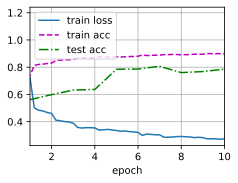

In [19]:
lr, num_epochs, batch_size = 1.0, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

In [ ]:
net[1].gamma.reshape((-1,)), net[1].beta.reshape((-1,))

### 简明实现

In [22]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10)
)

下⾯，我们使⽤相同超参数来训练模型。请注意，通常⾼级API变体运⾏速度快得多，因为它的代码已编译为C++或CUDA，⽽我们的⾃定义代码由Python实现。

loss 0.270, train acc 0.900, test acc 0.867
22797.9 examples/sec on cpu


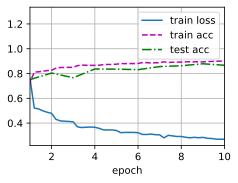

In [23]:
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

### 争议

总之，批量规范化在发展中有争议。\
但批量规范化已经被证明是⼀种不可或缺的⽅法。它适⽤于⼏乎所有图像分类器，并在学术界获得了数万引⽤。

### 练习

在使用批量规范化之前，我们是否可以从全连接层或卷积层中删除偏置参数？为什么？

可以。BatchNorm的作用是对每个batch的数据进行规范化，使得每个batch的数据分布相同，从而加速模型训练。因此，BatchNorm可以替代全连接层或卷积层中的偏置参数，因为它可以自动地学习偏置参数。

我们是否需要在每个层中进行批量规范化？尝试一下？

一般来说，BatchNorm可以在卷积层和全连接层之间使用，也可以在激活函数之前或之后使用。但是，并不是所有的层都需要使用BatchNorm，有时候使用过多的BatchNorm反而会降低模型性能。

可以通过批量规范化来替换暂退法吗？行为会如何改变？

可以，但一般是直接进行替换，不会同时用，因为二者都是起到正则项的作用。

## 残差网络(ResNet)

对于深度神经⽹络，如果我们能将新添加的层训练成恒等映射（identity function）$f(x) = x$，新模型和原模型将同样有效。同时，由于新模型可能得出更优的解来拟合训练数据集，因此添加层似乎更容易降低训练误差。

残差⽹络的核⼼思想是：每个附加层都应该更容易地包含原始函数作为其元素之⼀。于是，残差块（residual blocks）便诞⽣了，这个设计对如何建⽴深层神经⽹络产⽣了深远的影响。

### 残差块

让我们聚焦于神经⽹络局部：如图所⽰，假设我们的原始输⼊为x，⽽希望学出的理想映射为f(x)（作为图上⽅激活函数的输⼊）。左图虚线框中的部分需要直接拟合出该映射f(x)，⽽右图虚线框中的部分则需要拟合出残差映射f(x) − x。残差映射在现实中往往更容易优化。以本节开头提到的恒等映射作为我们希望学出的理想映射f(x)，我们只需将图中右图虚线框内上⽅的加权运算（如仿射）的权重和偏置参数设成0，那么f(x)即为恒等映射。实际中，当理想映射f(x)极接近于恒等映射时，残差映射也易于捕捉恒等映射的细微波动。右图是ResNet的基础架构‒残差块（residual block）。在残差块中，输⼊可通过跨层数据线路更快地向前传播。

<div align="center">
    <img src="../img/残差块.png">
<div>

In [37]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

class Residual(nn.Module):
    def __init__(self, input_channels, num_channels,
                use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                                kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                                kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                    kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

ResNet沿⽤了VGG完整的3 × 3卷积层设计。残差块⾥⾸先有2个有相同输出通道数的3 × 3卷积层。每个卷积层后接⼀个批量规范化层和ReLU激活函数。然后我们通过跨层数据通路，跳过这2个卷积运算，将输⼊直接加在最后的ReLU激活函数前。这样的设计要求2个卷积层的输出与输⼊形状⼀样，从⽽使它们可以相加。如果想改变通道数，就需要引⼊⼀个额外的1 × 1卷积层来将输⼊变换成需要的形状后再做相加运算。
<div align="center">
    <img src="../img/残差块.png">
<div>

In [38]:
blk = Residual(3, 3)
X = torch.rand(4, 3, 6, 6)
Y = blk(X)
Y.shape

torch.Size([4, 3, 6, 6])

In [39]:
blk = Residual(3, 6, use_1x1conv=True, strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

### ResNet模型

In [40]:
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                    nn.BatchNorm2d(64), nn.ReLU(),
                    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第⼀个模块的通道数同输⼊通道数⼀致。由于之前已经使⽤了步幅为2的最⼤汇聚层，所以⽆须减⼩⾼和宽。之后的每个模块在第⼀个残差块⾥将上⼀个模块的通道数翻倍，并将⾼和宽减半。

In [41]:
def resnet_block(input_channels, num_channels, num_residuals,
                first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))

    return blk

In [42]:
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))

In [43]:
net = nn.Sequential(b1, b2, b3, b4, b5,
                    nn.AdaptiveAvgPool2d((1, 1)),
                    nn.Flatten(), nn.Linear(512, 10))

In [44]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 128, 28, 28])
Sequential output shape:	 torch.Size([1, 256, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


### 训练模型

KeyboardInterrupt: 

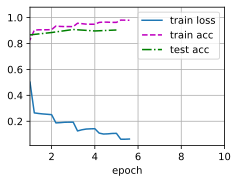

In [45]:
lr, num_epochs, batch_size = 0.05, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

总结一下：
1. 假设我们需要学习的函数为$H(x)$，普通的网络是直接学习目标映射$H(x)$，而残差网络学习$H(x)=F(x) + x$，通过$F(x) + xF(x) + x$降低深层网络的学习难度，若最优接近恒等，只需 $F(x)≈0$，比硬学 $H(x)≈x$ 容易，从而降低深层网络的优化难度。
2. 残差能够训练更深的网络，性能通常更好。残差能训练更深的网络，性能通常更好。捷径使 对 $y = F(x) + x$ 求导有 $\frac{\partial y}{\partial x} = \frac{\partial F}{\partial x} + 1$，即使$F$路径梯度很小，仍有接近1的通路回传，缓解梯度消失，使深层更易优化。

### 练习

为什么即使函数类是嵌套的，我们仍然要限制增加函数的复杂性呢？

因为过于复杂的函数会导致过拟合，从而降低模型的泛化能力。

## 稠密链接网络(DenseNet)

回想一下任意函数的泰勒展开式（Taylor expansion），它把这个函数分解成越来越高阶的项。在$x$接近0时，

$$
f(x) = f(0) + f'(0)x + \frac{f''(0)}{2!}x^2 + \frac{f'''(0)}{3!}x^3 + \dots 
$$

同样，ResNet将函数展开为

$$
f(\mathbf{x}) = \mathbf{x} + g(\mathbf{x})
$$

也就是说，ResNet将$f$分解为两部分：一个简单的线性项和一个复杂的非线性项。那么再向前拓展一步，如果我们想将$f$拓展成超过两部分的信息呢？一种方案便是DenseNet。

<div align="center">
    <img src="../img/ResNet与DenseNet区别.png">
<div>
ResNet（左）与 DenseNet（右）在跨层连接上的主要区别：使⽤相加和使⽤连结。

稠密⽹络主要由2部分构成：稠密块（dense block）和过渡层（transition layer）。前者定义如何连接输⼊和输出，⽽后者则控制通道数量，使其不会太复杂。

### 稠密块体

DenseNet使⽤了ResNet改良版的“批量规范化、激活和卷积”架构。

In [46]:
import torch
from torch import nn
from d2l import torch as d2l

def conv_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1)
    )

⼀个稠密块由多个卷积块组成，每个卷积块使⽤相同数量的输出通道。然⽽，在前向传播中，我们将每个卷积块的输⼊和输出在通道维上连结。

In [47]:
class DenseBlock(nn.Module):
    def __init__(self, num_convs, input_channels, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(
                num_channels * i + input_channels, num_channels
            ))
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            # 连接通道维度上每个块的输入和输出
            X = torch.cat((X, Y), dim=1)
        return X

In [48]:
blk = DenseBlock(2, 3, 10)
X = torch.randn(4, 3, 8, 8)
Y = blk(X)
Y.shape

torch.Size([4, 23, 8, 8])

### 过渡层

由于每个稠密块都会带来通道数的增加，使⽤过多则会过于复杂化模型。⽽过渡层可以⽤来控制模型复杂度。它通过1 × 1卷积层来减⼩通道数，并使⽤步幅为2的平均汇聚层减半⾼和宽，从⽽进⼀步降低模型复杂度。

In [49]:
def transition_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2)
    )

In [50]:
blk = transition_block(23, 10)
blk(Y).shape

torch.Size([4, 10, 4, 4])

### DenseNet模型

In [51]:
b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.BatchNorm2d(64), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

In [52]:
# num_channels为当前的通道数
num_channels, growth_rate = 64, 32
num_convs_in_dense_blocks = [4, 4, 4, 4]
blks = []
for i, num_convs in enumerate(num_convs_in_dense_blocks):
    blks.append(DenseBlock(num_convs, num_channels, growth_rate))
    # 上一个稠密块的输出通道数
    num_channels += num_convs * growth_rate
    # 在稠密块之间添加一个转换层，使通道数量减半
    if i != len(num_convs_in_dense_blocks) - 1:
        blks.append(transition_block(num_channels, num_channels // 2))
        num_channels = num_channels // 2

net = nn.Sequential(
    b1, *blks,
    nn.BatchNorm2d(num_channels), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(num_channels, 10)
)

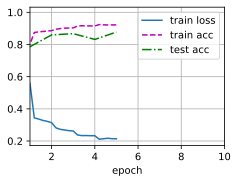

In [ ]:
lr, num_epochs, batch_size = 0.1, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

### 练习

为什么我们在过渡层使用平均汇聚层而不是最大汇聚层？

因为平均汇聚层可以更好地保留特征图中的信息，而最大汇聚层会丢失一些信息。

DenseNet一个诟病的问题是内存或显存消耗过多。

1. 真的是这样吗？可以把输入形状换成224×224，来看看实际的显存消耗。
2. 有另一种方法来减少显存消耗吗？需要改变框架么？
---
1. 是的，每一层卷积都要把输入拼接在一起，并且反向传播也需要存储，所以导致显存占用大。
2. 除了减小输入张量的大小，以下策略也可能有助于减少网络的显存消耗：
- 减少网络复杂性：可通过减小DenseNet网络中层的数量，或者减小每层中的神经元数量来实现。例如，您可以选择小一些的DenseNet结构（如DenseNet121），或者自定义一个更小的DenseNet。但是请注意，这样做可能会影响网络的性能。
- 采用模型压缩技术：模型压缩技术如权重量化、知识蒸馏等可以有效地减少网络对显存的需求，且通常能保持原始网络的性能。
- 改变优化器：一些优化器例如Adam，由于存储了大量的梯度信息，可能会导致显存使用增加。使用像SGD这样的优化器可能对显存需求更小。
- 混合精度训练：混合精度训练是一种在训练过程中同时使用float32和float16数据类型的方法，能够有效节省显存消耗，同时一般不会对模型精度产生太大影响。需要注意的是，硬件必须支持float16运算。
- 梯度累积：在PyTorch等框架中，可以利用梯度累积技术减小batch size，每次前向传播计算得到梯度后并不立即更新参数，而是累积几次梯度后再更新，这样可以在不损失模型性能的情况下有效降低显存占用。

通常情况下，无需因此改变框架。